# **Laboratorio: Análisis de Componentes Principales (PCA)**

* **Curso:** Inteligencia Artificial CC421


En este cuaderno, programaremos el algoritmo desde cero, y lo visualizaremos interactivamente para desarrollar una intuición geométrica.


## **Objetivos de aprendizaje:**
1.  **Intuir** la necesidad de reducción dimensional desde una perspectiva física y geométrica.
2.  **Formalizar** PCA como un problema de optimización de varianza con restricciones, derivando su solución mediante el problema de autovalores.
3.  **Implementar** PCA desde cero usando solo `NumPy`.
4.  **Analizar** la elección de dimensionalidad mediante la varianza explicada y el error de reconstrucción.
5.  **Explorar** las limitaciones de PCA en datos no lineales y su elegante conexión con la Descomposición en Valores Singulares (SVD).


---

## 1. INTRODUCCIÓN INTUITIVA: La Maldición y la Bendición de la Dimensionalidad

**¿Qué es PCA?**
El Análisis de Componentes Principales es un método estadístico no supervisado que transforma un conjunto de variables posiblemente correlacionadas en un nuevo conjunto de variables no correlacionadas llamadas **componentes principales**.

**El problema de la alta dimensionalidad**
En la era del *Big Data*, a menudo nos enfrentamos a conjuntos de datos con cientos o miles de variables (dimensiones). Esto acarrea problemas como:

*   **La maldición de la dimensionalidad:** La cantidad de datos necesaria para muestrear densamente el espacio crece exponencialmente con el número de dimensiones.
*   **Redundancia:** Muchas variables suelen medir fenómenos subyacentes relacionados, creando multicolinealidad.
*   **Visualización:** No podemos graficar directamente más de 3 dimensiones, lo que dificulta enormemente el análisis exploratorio.

**La idea fundamental: Reducción de dimensión**
PCA aborda esto encontrando un **subespacio de menor dimensión** que capture la máxima variabilidad (información) de los datos originales.

**Interpretación geométrica**
Geométricamente, PCA consiste en:

1.  **Proyección:** Proyectar los puntos de datos sobre un nuevo hiperplano (una línea en 2D, un plano en 3D, etc.).
2.  **Cambio de base:** Encontrar una nueva base ortonormal para el espacio vectorial de las variables, donde los nuevos "ejes" (los componentes principales) apunten en las direcciones de máxima varianza secuencial.

In [4]:
# @title **Celda de Código 1: Importación de Librerías**
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA as PCA_sklearn
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, interactive, fixed, FloatSlider, IntSlider
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

In [3]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---

## 2. EJEMPLO MOTIVADOR: El Misterio del Masa-Resorte

Para entender por qué PCA es tan poderoso, imaginemos un experimento físico clásico: un sistema masa-resorte en dos dimensiones.

**El sistema físico:**
Pensemos en una masa que se desliza sobre una mesa sin fricción, sujeta a un resorte cuyo otro extremo está fijo en el origen. La masa oscila a lo largo de una línea diagonal. Dos cámaras, ¡un poco defectuosas!, miden su posición. Una cámara registra una combinación lineal de las coordenadas $(x, y)$, `Sensor A = 2x + y`, y la otra `Sensor B = x - y`. Ambas mediciones tendrán ruido.

**Generación de datos simulados:**
Los datos del "movimiento real" están intrínsecamente en una dimensión (a lo largo de la línea de oscilación), pero nuestras mediciones nos dan observaciones ruidosas en dos dimensiones $(X_1, X_2)$. ¿Podemos recuperar la variable latente unidimensional?

In [ ]:
# @title **Celda de Código 2: Simulación del Sistema Masa-Resorte**
np.random.seed(42)
n = 150  # Número de observaciones

# 1. Variable latente (posición real a lo largo de la línea de oscilación)
# La masa describe un movimiento armónico simple (aprox.)
t = np.linspace(0, 3*np.pi, n)
trayectoria_real = 3 * np.sin(1.5 * t)  # Movimiento unidimensional

# 2. Base original (ejes canónicos x, y) rotada 45 grados
theta = np.pi / 4
u1 = np.array([np.cos(theta), np.sin(theta)])  # Dirección de oscilación
pose_real_x = trayectoria_real * u1[0]
pose_real_y = trayectoria_real * u1[1]

# 3. Mediciones de dos sensores ruidosos (combinaciones lineales de la posición real)
sensor_A = 2 * pose_real_x + pose_real_y + np.random.normal(0, 0.8, n)
sensor_B = pose_real_x - pose_real_y + np.random.normal(0, 0.6, n)

# Matriz de datos X (n_samples, n_features) = (150, 2)
X_masa = np.column_stack((sensor_A, sensor_B))

print("Forma de la matriz de datos del experimento masa-resorte:", X_masa.shape)
print("Observamos 2 variables (dimensiones) pero sabemos que hay solo 1 variable física fundamental.")

Forma de la matriz de datos del experimento masa-resorte: (150, 2)
Observamos 2 variables (dimensiones) pero sabemos que hay solo 1 variable física fundamental.


**Visualización: La dirección principal**
Si graficamos las mediciones de los dos sensores, veremos una nube de puntos alargada. La dirección de máximo alargamiento no corresponde ni a `Sensor A` ni a `Sensor B`, sino a una combinación lineal de ambos. Esa es la **dirección principal** que PCA descubre automáticamente.

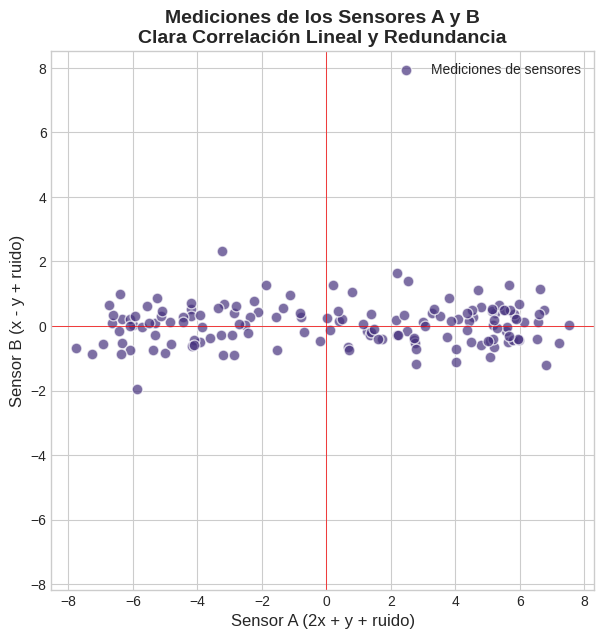

In [ ]:
# @title **Celda de Código 3: Visualización de la Redundancia**
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(X_masa[:, 0], X_masa[:, 1], alpha=0.7, edgecolors='w', s=60, label='Mediciones de sensores')
ax.set_xlabel('Sensor A (2x + y + ruido)', fontsize=12)
ax.set_ylabel('Sensor B (x - y + ruido)', fontsize=12)
ax.set_title('Mediciones de los Sensores A y B\nClara Correlación Lineal y Redundancia', fontsize=14, fontweight='bold')
ax.axhline(0, color='red', lw=0.5)
ax.axvline(0, color='red', lw=0.5)
ax.axis('equal')
ax.legend()
plt.show()

**Explicación de la redundancia:**
Aquí radica la clave. Aunque tenemos dos mediciones, la información está casi completamente contenida en una sola dimensión. La alta correlación entre `Sensor A` y `Sensor B` implica redundancia: conocer una nos da una estimación muy precisa de la otra. PCA nos permitirá encontrar esa única dimensión subyacente que explica la mayor parte de la varianza del sistema, filtrando el ruido.

---

## 3. FORMALISMO MATEMÁTICO

Ahora que tenemos la intuición, construyamos el formalismo matemático. PCA es un proceso axiomático que se deriva de un objetivo claro.

---

### 3.1. Pre-procesamiento: Centrado de los Datos

El primer paso es centrar la matriz de datos. Sea $\mathbf{X} \in \mathbb{R}^{n \times d}$ nuestra matriz de datos, con $n$ observaciones y $d$ variables. La matriz centrada $\mathbf{X}_c$ se obtiene restando a cada columna su media:
$$ \mathbf{X}_c = \mathbf{X} - \mathbf{1}_n \boldsymbol{\mu}^T $$
donde $\boldsymbol{\mu} \in \mathbb{R}^d$ es el vector de medias de cada variable, $\boldsymbol{\mu} = \frac{1}{n} \mathbf{X}^T \mathbf{1}_n$.

---

### 3.2. Matriz de Covarianza: Midiendo Relaciones

La matriz de covarianza muestral insesgada se define como:
$$ \mathbf{S} = \frac{1}{n-1} \mathbf{X}_c^T \mathbf{X}_c $$
En PCA, a menudo usamos la versión de máxima verosimilitud $\boldsymbol{\Sigma} = \frac{1}{n} \mathbf{X}_c^T \mathbf{X}_c$. La diferencia es un factor de escala que no afecta los autovectores. $\boldsymbol{\Sigma}$ es una matriz simétrica y semidefinida positiva. Sus elementos diagonales $\Sigma_{jj}$ son las varianzas de cada variable, y sus elementos fuera de la diagonal $\Sigma_{jk}$ son las covarianzas entre las variables $j$ y $k$.

---

### 3.3. El Problema de Optimización: Maximizar Varianza

El primer componente principal (PC1) es la dirección unitaria $\mathbf{w}_1 \in \mathbb{R}^d$ que maximiza la varianza de los datos proyectados sobre ella. La proyección de $\mathbf{X}_c$ sobre $\mathbf{w}_1$ es el vector fila $\mathbf{z}_1 = \mathbf{X}_c \mathbf{w}_1$.

Queremos maximizar la varianza de esta proyección, $\text{Var}(\mathbf{z}_1)$, sujeta a la restricción de que el vector de carga sea unitario, $\|\mathbf{w}_1\|_2 = 1$.

$$ \max_{\mathbf{w}_1} \ \frac{1}{n} \| \mathbf{X}_c \mathbf{w}_1 \|^2 \quad \text{sujeto a} \quad \|\mathbf{w}_1\|_2 = 1 $$

---

### 3.4. Derivación del Problema de Autovalores

Expandimos la función objetivo (la varianza proyectada):
$$ \frac{1}{n} \| \mathbf{X}_c \mathbf{w}_1 \|^2 = \frac{1}{n} (\mathbf{X}_c \mathbf{w}_1)^T (\mathbf{X}_c \mathbf{w}_1) = \mathbf{w}_1^T \left( \frac{1}{n} \mathbf{X}_c^T \mathbf{X}_c \right) \mathbf{w}_1 = \mathbf{w}_1^T \boldsymbol{\Sigma} \mathbf{w}_1 $$

Este es un problema de optimización cuadrática con restricción de igualdad. Planteamos el Lagrangiano:
$$ \mathcal{L}(\mathbf{w}_1, \lambda_1) = \mathbf{w}_1^T \boldsymbol{\Sigma} \mathbf{w}_1 - \lambda_1 (\mathbf{w}_1^T \mathbf{w}_1 - 1) $$

Derivamos respecto a $\mathbf{w}_1$ e igualamos a cero (condición de optimalidad de primer orden):
$$ \frac{\partial \mathcal{L}}{\partial \mathbf{w}_1} = 2 \boldsymbol{\Sigma} \mathbf{w}_1 - 2 \lambda_1 \mathbf{w}_1 = 0 $$

**Resultado fundamental:**
$$ \boxed{\boldsymbol{\Sigma} \mathbf{w}_1 = \lambda_1 \mathbf{w}_1} $$

¡Esto es un problema de autovalores y autovectores! La ecuación nos dice que la dirección óptima $\mathbf{w}_1$ es un autovector de la matriz de covarianzas $\boldsymbol{\Sigma}$. El multiplicador de Lagrange $\lambda_1$ es el autovalor asociado.

Si premultiplicamos por $\mathbf{w}_1^T$, vemos que $\mathbf{w}_1^T \boldsymbol{\Sigma} \mathbf{w}_1 = \lambda_1$. Por lo tanto, la varianza máxima a lo largo de la primera componente principal es exactamente el autovalor $\lambda_1$. Para maximizarla, elegimos el autovector correspondiente al **mayor autovalor**.

Los componentes subsiguientes $\mathbf{w}_j$ se encuentran iterativamente, maximizando la varianza restante en el subespacio ortogonal a todos los componentes anteriores. La solución completa es la descomposición espectral de $\boldsymbol{\Sigma}$:
$$ \boldsymbol{\Sigma} \mathbf{W} = \mathbf{W} \boldsymbol{\Lambda} $$
donde $\mathbf{W}$ es la matriz ortogonal de autovectores (cargas) y $\boldsymbol{\Lambda} = \text{diag}(\lambda_1, \dots, \lambda_d)$ es la matriz diagonal de autovalores, con $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_d \ge 0$.

---

## 4. INTERPRETACIÓN GEOMÉTRICA AVANZADA

Los **autovectores** ($\mathbf{w}_j$) forman los ejes de un nuevo sistema de coordenadas, las **direcciones principales**. Rotan el espacio original hacia donde la varianza es máxima.

Los **autovalores** ($\lambda_j$) cuantifican la varianza a lo largo de su correspondiente dirección principal. Gráficamente, la raíz cuadrada de un autovalor, $\sqrt{\lambda_j}$, es proporcional a la longitud del semieje de la elipse (o elipsoide en 3D) que envuelve los datos.

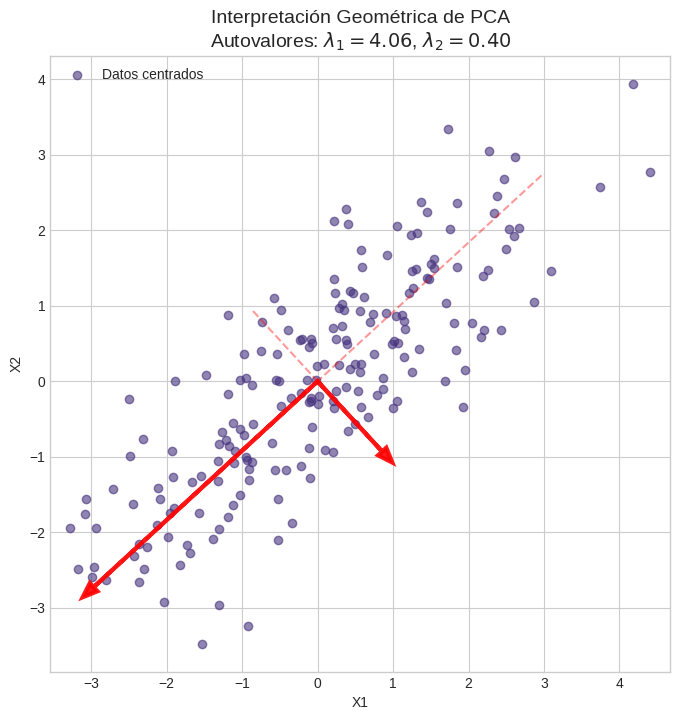

In [ ]:
# @title **Celda de Código 4: Visualización Geométrica en Datos Simulados 2D**
np.random.seed(24)
# Datos con correlación
mean = [3, 4]
cov = [[2.5, 1.8], [1.8, 2.0]]  # Matriz de covarianza definida positiva
X_geo = np.random.multivariate_normal(mean, cov, 200)

# Centramos los datos
X_geo_c = X_geo - np.mean(X_geo, axis=0)

# Calculamos autovectores y autovalores
eigvals, eigvecs = np.linalg.eigh(np.cov(X_geo_c.T))  # eigh para matrices simétricas
# eigh los devuelve en orden ascendente, los invertimos
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# Gráfico
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X_geo_c[:, 0], X_geo_c[:, 1], alpha=0.6, label='Datos centrados')

# Dibujar ejes principales
mean_centered = np.mean(X_geo_c, axis=0)
for i in range(len(eigvals)):
    # Escalar el autovector por la raíz del autovalor para la longitud del eje
    vector = eigvecs[:, i] * np.sqrt(eigvals[i]) * 2
    ax.arrow(mean_centered[0], mean_centered[1], vector[0], vector[1],
              head_width=0.15, head_length=0.2, fc='red', ec='red', linewidth=3, alpha=0.9)
    ax.plot([mean_centered[0] - vector[0], mean_centered[0] + vector[0]],
             [mean_centered[1] - vector[1], mean_centered[1] + vector[1]], 'r--', alpha=0.4)

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title(f'Interpretación Geométrica de PCA\nAutovalores: $\lambda_1={eigvals[0]:.2f}$, $\lambda_2={eigvals[1]:.2f}$', fontsize=14)
ax.axis('equal')
ax.legend()
plt.show()

---

## 5. IMPLEMENTACIÓN DESDE CERO: PCA Puro con NumPy

Es momento de implementar lo aprendido. La teoría es elegante, y su código es sorprendentemente conciso.

In [ ]:
# @title **Celda de Código 5: Clase PCA desde Cero**
class PCA_FromScratch:
    """
    Clase para realizar Análisis de Componentes Principales.

    Atributos:
        media_ (np.ndarray): Media de los datos de entrenamiento.
        componentes_ (np.ndarray): Matriz W de autovectores (ordenados por autovalor descendente).
        autovalores_ (np.ndarray): Vector de autovalores en orden descendente.
        varianza_explicada_proporcion_ (np.ndarray): Proporción de varianza explicada por cada componente.
    """
    def __init__(self, n_componentes=None):
        self.n_componentes = n_componentes
        self.media_ = None
        self.componentes_ = None
        self.autovalores_ = None
        self.varianza_explicada_proporcion_ = None

    def ajustar(self, X):
        """
        Ajusta el modelo PCA a los datos.
        Pasos:
        1. Centrar los datos: X_c = X - μ
        2. Calcular matriz de covarianza: Σ = (1/n) X_c^T X_c
        3. Descomposición espectral de Σ.
        """
        # Paso 1: Centrar
        self.media_ = np.mean(X, axis=0)
        X_c = X - self.media_

        # Paso 2: Covarianza
        n = X_c.shape[0]
        Sigma = (1 / n) * X_c.T @ X_c  # Usamos la versión de máxima verosimilitud

        # Paso 3: Eigen-decomposition
        # np.linalg.eigh es eficiente para matrices simétricas como Σ
        autovalores, autovectores = np.linalg.eigh(Sigma)

        # Ordenar en orden descendente
        idx_orden = np.argsort(autovalores)[::-1]
        self.autovalores_ = autovalores[idx_orden]
        self.componentes_ = autovectores[:, idx_orden]

        # Varianza explicada
        varianza_total = np.sum(self.autovalores_)
        self.varianza_explicada_proporcion_ = self.autovalores_ / varianza_total

        if self.n_componentes is not None:
            self.componentes_ = self.componentes_[:, :self.n_componentes]

    def transformar(self, X):
        """
        Proyecta los datos centrados al nuevo espacio PCA.
        Z = X_c W
        """
        X_c = X - self.media_
        return X_c @ self.componentes_

    def reconstruir(self, Z):
        """
        Reconstruye los datos desde el espacio reducido de vuelta al original.
        X_reconstruido = Z W^T + μ
        """
        X_reconstruido_centered = Z @ self.componentes_.T
        return X_reconstruido_centered + self.media_

# Verificación rápida con nuestro ejemplo de masa-resorte
pca_masa_scratch = PCA_FromScratch(n_componentes=2)
pca_masa_scratch.ajustar(X_masa)

print("Componentes principales (cargas) encontrados:")
print(pca_masa_scratch.componentes_)
print("\nAutovalores:")
print(pca_masa_scratch.autovalores_)
print("\nProporción de Varianza Explicada:")
print(pca_masa_scratch.varianza_explicada_proporcion_)

Componentes principales (cargas) encontrados:
[[-0.99997632  0.00688203]
 [-0.00688203 -0.99997632]]

Autovalores:
[20.05508835  0.37236554]

Proporción de Varianza Explicada:
[0.98177132 0.01822868]


---

## 6. PROYECCIÓN Y REDUCCIÓN DE DIMENSIONALIDAD

El poder de PCA reside en la reducción. Podemos usar solo los primeros $k$ componentes $(k < p)$ para proyectar los datos a un espacio de menor dimensión, filtrando ruido y reteniendo la estructura principal.

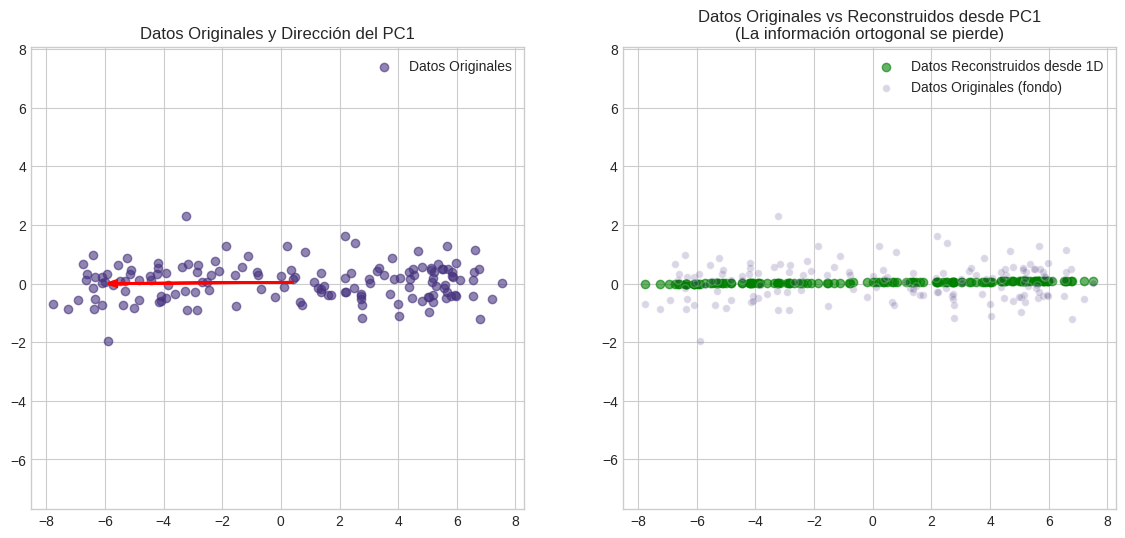

Forma de los datos originales: (150, 2)
Forma de los datos proyectados en 1D: (150, 1)
¡Reducción de dimensionalidad exitosa!


In [ ]:
# @title **Celda de Código 6: Proyectando a 1D y Visualizando**
# Ajustamos PCA con 1 componente
pca_1d = PCA_FromScratch(n_componentes=1)
pca_1d.ajustar(X_masa)

# Transformar datos a 1D
Z_masa_1d = pca_1d.transformar(X_masa)

# Reconstruir a 2D
X_masa_reconstruida = pca_1d.reconstruir(Z_masa_1d)

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Datos originales con dirección PCA
ax0 = axes[0]
ax0.scatter(X_masa[:, 0], X_masa[:, 1], alpha=0.6, label='Datos Originales')
dir_pc1 = pca_1d.componentes_[:, 0] * 6
ax0.arrow(pca_1d.media_[0], pca_1d.media_[1], dir_pc1[0], dir_pc1[1],
          head_width=0.2, head_length=0.3, fc='red', ec='red', lw=2)
ax0.set_title('Datos Originales y Dirección del PC1')
ax0.axis('equal')
ax0.legend()

# Datos reconstruidos
ax1 = axes[1]
ax1.scatter(X_masa_reconstruida[:, 0], X_masa_reconstruida[:, 1], alpha=0.6, color='green', label='Datos Reconstruidos desde 1D')
ax1.scatter(X_masa[:, 0], X_masa[:, 1], alpha=0.2, edgecolors='w', s=30, label='Datos Originales (fondo)')
ax1.set_title('Datos Originales vs Reconstruidos desde PC1\n(La información ortogonal se pierde)')
ax1.legend()
ax1.axis('equal')
plt.show()

print("Forma de los datos originales:", X_masa.shape)
print("Forma de los datos proyectados en 1D:", Z_masa_1d.shape)
print("¡Reducción de dimensionalidad exitosa!")

---

## 7. VARIANZA EXPLICADA Y ELEGIR `k`

¿Cómo elegimos el número óptimo de componentes $k$? La proporción de varianza explicada acumulada es la métrica estándar.

$$ \text{VE}_{\text{acum}}(k) = \frac{\sum_{j=1}^k \lambda_j}{\sum_{j=1}^d \lambda_j} $$

El **Scree plot** (gráfico de sedimentación) nos permite visualizar la "importancia" de cada componente.

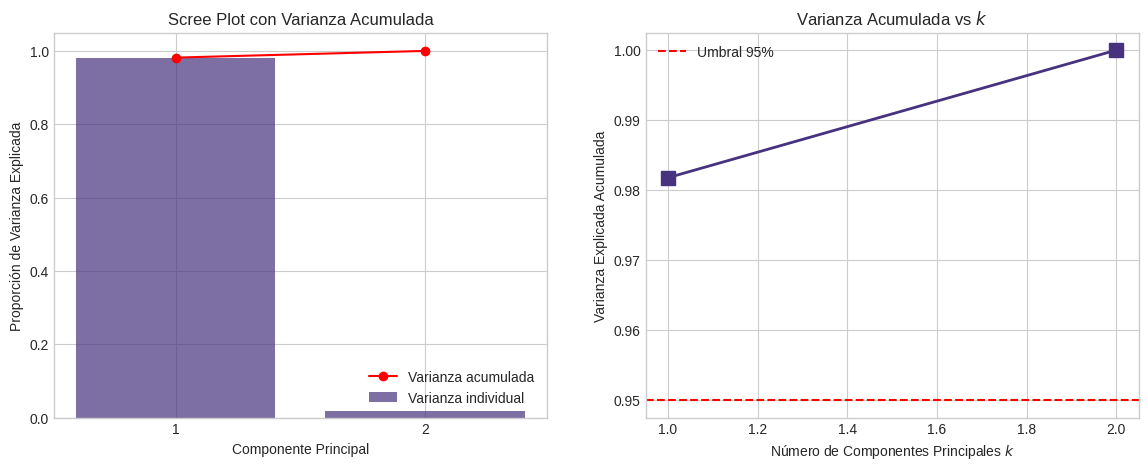

Para el sistema masa-resorte, 1 componente explica más del 95% de la varianza.


In [ ]:
# @title **Celda de Código 7: Scree Plot y Varianza Explicada Acumulada**
# Usamos la implementación de sklearn para mayor compatibilidad (o la nuestra)
pca_full = PCA_FromScratch()
pca_full.ajustar(X_masa)

varianza_prop = pca_full.varianza_explicada_proporcion_
varianza_acum = np.cumsum(varianza_prop)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree Plot
axes[0].bar(range(1, len(varianza_prop)+1), varianza_prop, alpha=0.7, label='Varianza individual')
axes[0].plot(range(1, len(varianza_prop)+1), varianza_acum, 'ro-', label='Varianza acumulada')
axes[0].set_xticks(range(1, len(varianza_prop)+1))
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Proporción de Varianza Explicada')
axes[0].set_title('Scree Plot con Varianza Acumulada')
axes[0].legend()
axes[0].grid(True, axis='y')

# Gráfico de varianza acumulada con umbral del 95%
axes[1].plot(range(1, len(varianza_acum)+1), varianza_acum, 's-', markersize=10, linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
axes[1].set_xlabel('Número de Componentes Principales $k$')
axes[1].set_ylabel('Varianza Explicada Acumulada')
axes[1].set_title('Varianza Acumulada vs $k$')
axes[1].legend()
axes[1].grid(True)
plt.show()

print("Para el sistema masa-resorte, 1 componente explica más del 95% de la varianza.")

---

## 8. ERROR DE RECONSTRUCCIÓN: El Trade-off Dimensión vs. Pérdida

La reconstrucción nunca es perfecta si $k < p$. El error cuadrático medio de reconstrucción normalizado es una medida directa de la información perdida:
$$ \text{MSE}_{\text{norm}}(k) = \frac{\mathbb{E}[\|\mathbf{x} - \hat{\mathbf{x}}_k\|^2]}{\mathbb{E}[\|\mathbf{x}\|^2]} \propto 1 - \text{VE}_{\text{acum}}(k) $$

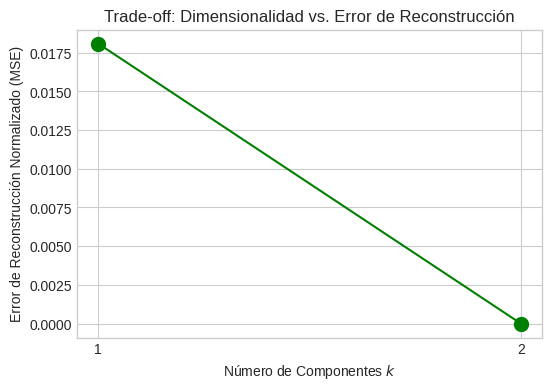

In [ ]:
# @title **Celda de Código 8: Error de Reconstrucción**
def error_reconstruccion(X, pca, ks):
    errores = []
    X_norm_cuadrado = np.mean(np.linalg.norm(X, axis=1)**2) # Para normalizar
    for k in ks:
        pca.n_componentes = k
        pca.ajustar(X)
        Z = pca.transformar(X)
        X_reconst = pca.reconstruir(Z)
        mse = np.mean(np.linalg.norm(X - X_reconst, axis=1)**2)
        errores.append(mse / X_norm_cuadrado)
    return errores

ks = [1, 2]
pca_err = PCA_FromScratch()
errores_masa = error_reconstruccion(X_masa, pca_err, ks)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, errores_masa, 'go-', markersize=10)
ax.set_xlabel('Número de Componentes $k$')
ax.set_ylabel('Error de Reconstrucción Normalizado (MSE)')
ax.set_title('Trade-off: Dimensionalidad vs. Error de Reconstrucción')
ax.set_xticks(ks)
ax.grid(True)
plt.show()

---

## 9. IMPLEMENTACIÓN CON SCIKIT-LEARN: La Práctica Estándar

`sklearn.decomposition.PCA` es una implementación altamente optimizada que usa SVD. Debemos conocerla a fondo.

In [ ]:
# @title **Celda de Código 9: PCA con Scikit-learn**
pca_sk = PCA_sklearn(n_components=2)
pca_sk.fit(X_masa)

print("=== Comparación de Resultados: FromScratch vs Scikit-learn ===")
print("\nComponentes (Scikit-learn):")
print(pca_sk.components_)  # Nota: En sklearn, components_ son los autovectores como FILAS.
print("\nComponentes (Nuestra implementación - columnas):")
print(pca_masa_scratch.componentes_)
print("\nSon equivalentes (salvo por signo, que es arbitrario en autovectores).")

print("\nVarianza Explicada (Scikit-learn):", pca_sk.explained_variance_ratio_)
print("Varianza Explicada (Nuestra implementación):", pca_masa_scratch.varianza_explicada_proporcion_)

=== Comparación de Resultados: FromScratch vs Scikit-learn ===

Componentes (Scikit-learn):
[[ 0.99997632  0.00688203]
 [-0.00688203  0.99997632]]

Componentes (Nuestra implementación - columnas):
[[-0.99997632  0.00688203]
 [-0.00688203 -0.99997632]]

Son equivalentes (salvo por signo, que es arbitrario en autovectores).

Varianza Explicada (Scikit-learn): [0.98177132 0.01822868]
Varianza Explicada (Nuestra implementación): [0.98177132 0.01822868]


---

## 10. EJEMPLOS ADICIONALES: PCA en Acción

### 10.1. El Clásico Dataset Iris

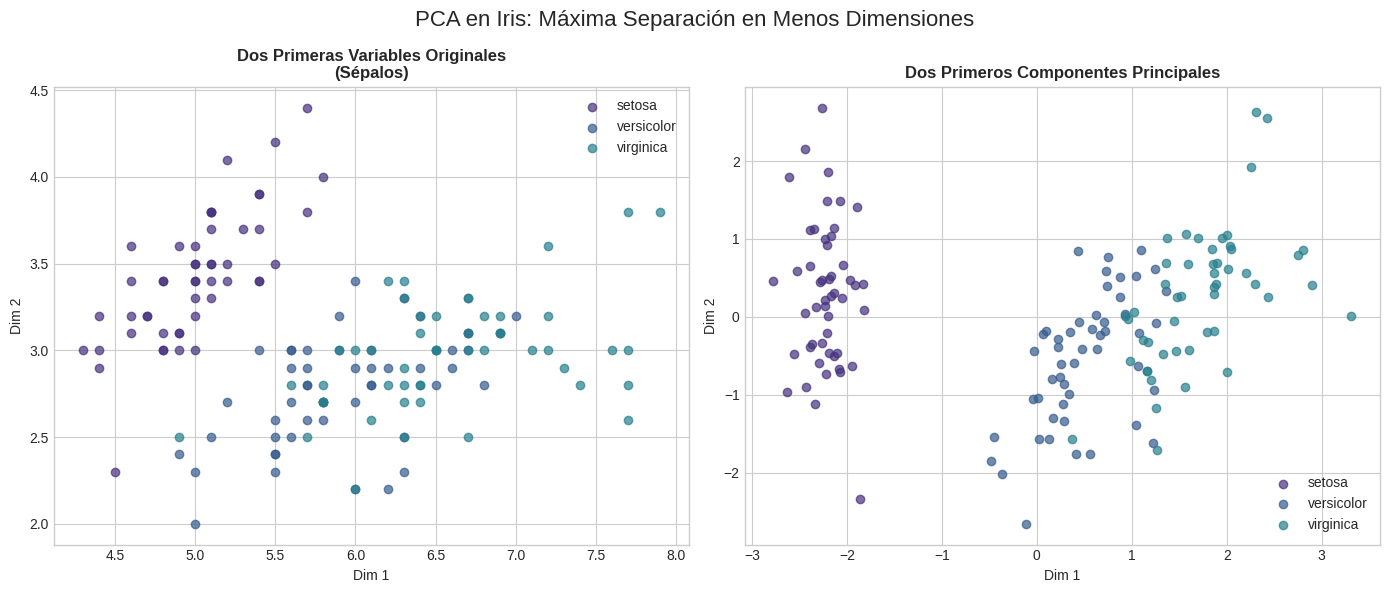

Observamos que PCA revela una estructura de clases mucho más clara.


In [ ]:
# @title **Celda de Código 10: PCA en Dataset Iris**
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
nombres_iris = iris.target_names

# PCA con Scikit-learn (estandarizando primero es crucial aquí)
X_iris_std = StandardScaler().fit_transform(X_iris)  # Para que las unidades no dominen
pca_iris = PCA_sklearn(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_std)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafico original (usando dos primeras features) vs PCA
for ax, X_plot, title in zip(axes, [X_iris[:, :2], X_iris_pca],
                              ['Dos Primeras Variables Originales\n(Sépalos)',
                               'Dos Primeros Componentes Principales']):
    for i, nombre in enumerate(nombres_iris):
        ax.scatter(X_plot[y_iris == i, 0], X_plot[y_iris == i, 1], label=nombre, alpha=0.7)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('PCA en Iris: Máxima Separación en Menos Dimensiones', fontsize=16)
plt.tight_layout()
plt.show()
print("Observamos que PCA revela una estructura de clases mucho más clara.")

### 10.2. Dataset Sintético No Lineal (Preámbulo a la sección de fallos)

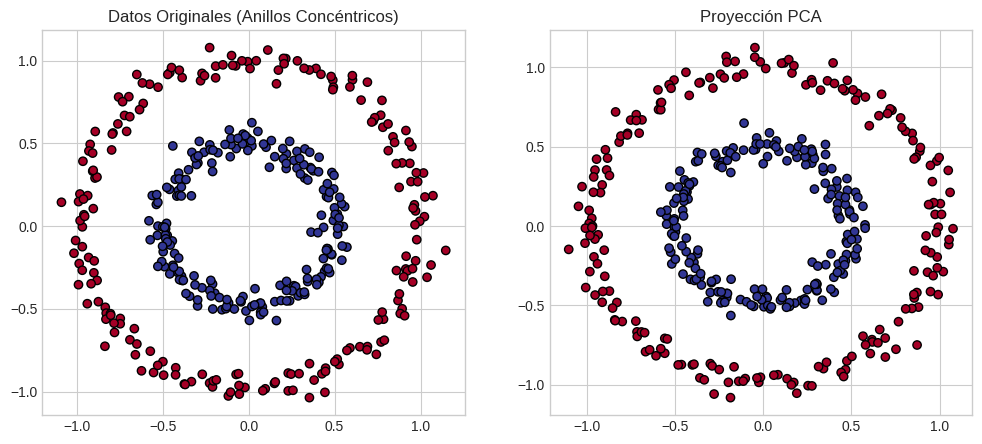

In [ ]:
# @title **Celda de Código 11: Dataset Sintético - Anillo Concéntrico**
from sklearn.datasets import make_circles
n_samples = 400
X_anillo, y_anillo = make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=42)

pca_anillo = PCA_sklearn(n_components=2)
X_anillo_pca = pca_anillo.fit_transform(X_anillo)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_anillo[:, 0], X_anillo[:, 1], c=y_anillo, cmap='RdYlBu', edgecolors='k')
axes[0].set_title('Datos Originales (Anillos Concéntricos)')
axes[1].scatter(X_anillo_pca[:, 0], X_anillo_pca[:, 1], c=y_anillo, cmap='RdYlBu', edgecolors='k')
axes[1].set_title('Proyección PCA')
plt.show()

---

## 11. VISUALIZACIONES AVANZADAS: Biplots y 3D

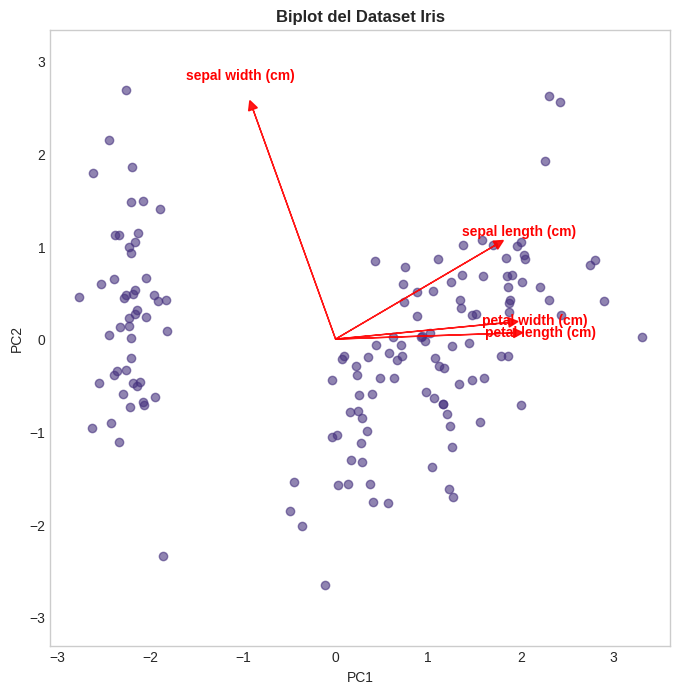

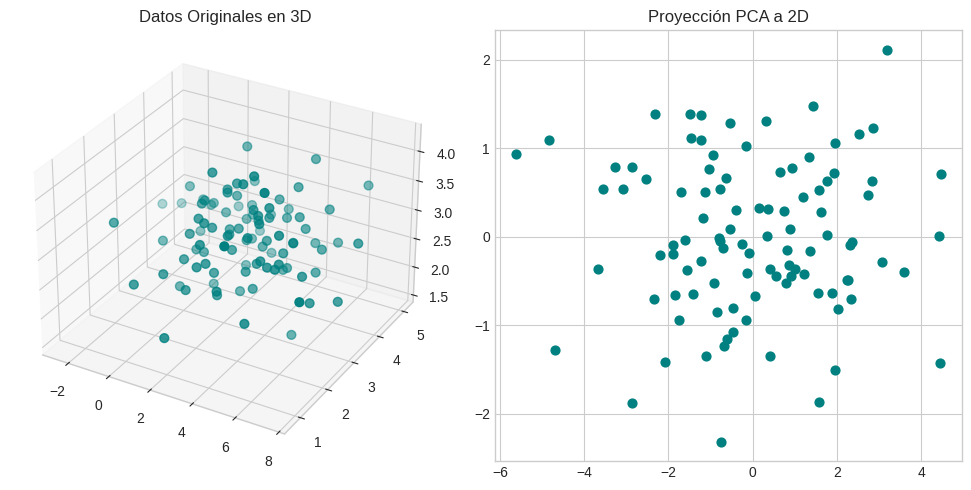

In [ ]:
# @title **Celda de Código 12: Biplot y Visualización 3D**
# Biplot: combina el scatter plot de los scores con los vectores de carga.
def biplot(scores, loadings, labels=None, title="Biplot"):
    plt.figure(figsize=(8, 8))
    xs = scores[:, 0]
    ys = scores[:, 1]
    plt.scatter(xs, ys, alpha=0.6)
    for i in range(loadings.shape[0]):
        plt.arrow(0, 0, loadings[i, 0]* np.max(xs), loadings[i, 1]* np.max(ys),
                  color='r', alpha=0.9, head_width=0.1, head_length=0.1)
        if labels is not None:
            plt.text(loadings[i, 0]*np.max(xs)*1.15, loadings[i, 1]*np.max(ys)*1.15,
                     labels[i], color='r', ha='center', va='center', fontweight='bold')
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.axis('equal')
    plt.title(title, fontweight='bold')
    plt.grid()
    plt.show()

# Biplot para Iris
pca_iris_biplot = PCA_sklearn(n_components=2)
scores_iris = pca_iris_biplot.fit_transform(X_iris_std)
biplot(scores_iris, pca_iris_biplot.components_.T, labels=iris.feature_names, title="Biplot del Dataset Iris")

# Visualización 3D para un dataset ficticio
np.random.seed(5)
X_3d = np.random.randn(100, 3) * [2, 1, 0.5] + [3, 3, 3]
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c='teal', s=40)
ax.set_title('Datos Originales en 3D')
pca_3d = PCA_sklearn(n_components=2)
X_3d_red = pca_3d.fit_transform(X_3d)
ax2 = fig.add_subplot(122)
ax2.scatter(X_3d_red[:, 0], X_3d_red[:, 1], c='teal', s=40)
ax2.set_title('Proyección PCA a 2D')
plt.tight_layout()
plt.show()

---

## 12. INTERACTIVIDAD: Controlando PCA en Tiempo Real

Usemos `ipywidgets` para construir una intuición dinámica sobre el efecto del ruido y la dimensionalidad.

In [ ]:
# @title **Celda de Código 13 (CORREGIDA): Widgets Interactivos - Ruido y Dimensionalidad**
def pca_interactivo(nivel_ruido=0.5, n_comp=1):
    np.random.seed(100)
    n = 100
    t = np.linspace(0, 2*np.pi, n)

    # Señal limpia
    X_limpio = np.column_stack([2*np.cos(t), np.sin(t)])

    # Añadir ruido
    ruido = np.random.normal(0, nivel_ruido, X_limpio.shape)
    X_ruidoso = X_limpio + ruido

    # Centrado manual robusto (siempre funciona con arrays numpy)
    media_ruidoso = np.mean(X_ruidoso, axis=0)
    X_ruidoso_c = X_ruidoso - media_ruidoso  # Broadcasting correcto (n,2) - (2,)

    # PCA completo (2 componentes para visualizar direcciones)
    pca = PCA_FromScratch(n_componentes=2)
    pca.ajustar(X_ruidoso)

    # Proyección y reconstrucción con k componentes
    pca_reduc = PCA_FromScratch(n_componentes=n_comp)
    pca_reduc.ajustar(X_ruidoso)
    Z = pca_reduc.transformar(X_ruidoso)
    X_reconstruida = pca_reduc.reconstruir(Z)

    # Para la visualización, centramos los datos reconstruidos
    media_reconstruida = np.mean(X_reconstruida, axis=0)
    X_reconstruida_c = X_reconstruida - media_reconstruida  # Corrección aquí

    # Gráfico
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 1. Datos originales y direcciones PCA
    axes[0].scatter(X_ruidoso_c[:, 0], X_ruidoso_c[:, 1], alpha=0.6,
                    c='steelblue', edgecolors='white', s=50)
    for i in range(2):
        vector = pca.componentes_[:, i] * np.sqrt(pca.autovalores_[i]) * 3
        axes[0].arrow(0, 0, vector[0], vector[1],
                     head_width=0.3, head_length=0.4, color='red', lw=2.5, alpha=0.8)
        axes[0].text(vector[0]*1.1, vector[1]*1.1, f'PC{i+1}',
                    color='red', fontweight='bold', fontsize=10)
    axes[0].set_title(f'Datos Ruidosos y Direcciones PC\nRuido σ = {nivel_ruido:.2f}',
                      fontweight='bold')
    axes[0].set_xlabel('Variable 1')
    axes[0].set_ylabel('Variable 2')
    axes[0].axis('equal')
    axes[0].grid(True, alpha=0.3)

    # 2. Error de Reconstrucción vs Originales
    # CORRECCIÓN: usar X_reconstruida_c en lugar de X_reconstruida - media_reconstruida
    axes[1].scatter(X_ruidoso_c[:, 0], X_ruidoso_c[:, 1], alpha=0.3,
                    label='Original', edgecolors='gray', linewidth=0.5)
    axes[1].scatter(X_reconstruida_c[:, 0], X_reconstruida_c[:, 1],
                    alpha=0.9, label=f'Reconstruido (k={n_comp})',
                    color='limegreen', edgecolors='darkgreen', linewidth=0.5)

    # Líneas de error (para visualizar la pérdida de información)
    for i in range(n):
        axes[1].plot([X_ruidoso_c[i, 0], X_reconstruida_c[i, 0]],
                    [X_ruidoso_c[i, 1], X_reconstruida_c[i, 1]],
                    'r-', alpha=0.15, linewidth=0.5)

    axes[1].set_title(f'Original vs Reconstruido (k={n_comp})\nLíneas rojas = error de proyección',
                      fontweight='bold')
    axes[1].set_xlabel('Variable 1')
    axes[1].set_ylabel('Variable 2')
    axes[1].axis('equal')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    # 3. Varianza Explicada
    varianza_acum = np.cumsum(pca.varianza_explicada_proporcion_)
    colores = ['steelblue', 'lightcoral']

    # Barras con etiquetas
    bars = axes[2].bar(range(1, 3), pca.varianza_explicada_proporcion_,
                       alpha=0.8, color=colores, edgecolor='black', linewidth=1.2,
                       label='Proporción Individual')

    # Añadir texto sobre las barras
    for i, (bar, val) in enumerate(zip(bars, pca.varianza_explicada_proporcion_)):
        axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f'{val:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

    # Línea de varianza acumulada
    axes[2].plot(range(1, 3), varianza_acum, 'ro-', linewidth=2.5, markersize=10,
                label='Proporción Acumulada')

    # Destacar el componente actual
    axes[2].axvline(x=n_comp, color='green', linestyle='--', alpha=0.7,
                    label=f'Umbral actual (k={n_comp})')

    axes[2].set_xticks([1, 2])
    axes[2].set_xlabel('Componente Principal', fontweight='bold')
    axes[2].set_ylabel('Proporción de Varianza Explicada', fontweight='bold')
    axes[2].set_title(f'Distribución de Varianza\n(Total = {np.sum(pca.autovalores_):.2f})',
                      fontweight='bold')
    axes[2].set_ylim(0, 1.15)
    axes[2].legend(loc='upper left', framealpha=0.9)
    axes[2].grid(axis='y', alpha=0.3)

    # Información adicional en el gráfico
    if n_comp == 1:
        texto_info = f"Usando PC1: {varianza_acum[0]:.1%} de varianza conservada"
    else:
        texto_info = f"Usando ambos PCs: 100% de varianza conservada"

    axes[2].text(1.5, 1.05, texto_info, ha='center', va='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=11)

    plt.suptitle('PCA Interactivo: Explorando Ruido y Dimensionalidad',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Crear los widgets interactivos
interact(pca_interactivo,
         nivel_ruido=FloatSlider(min=0.0, max=2.0, step=0.1, value=0.5,
                                 description='Ruido σ:',
                                 style={'description_width': 'initial'},
                                 layout=widgets.Layout(width='400px')),
         n_comp=IntSlider(min=1, max=2, step=1, value=1,
                         description='Componentes k:',
                         style={'description_width': 'initial'},
                         layout=widgets.Layout(width='400px')));

interactive(children=(FloatSlider(value=0.5, description='Ruido σ:', layout=Layout(width='400px'), max=2.0, st…

---

## 13. ANIMACIONES: El Cambio de Base en Movimiento

Las animaciones nos permiten "ver" la proyección progresiva. Ejecutemos este bloque para observar cómo los puntos rotan y se comprimen.

In [ ]:
# @title **Celda de Código 14: Animación del Cambio de Base**
# Configuración para Colab
from IPython.display import HTML, display
import matplotlib.animation as animation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Datos masa-resorte de la sección 2
X_anim = X_masa - np.mean(X_masa, axis=0)
pca_anim = PCA_FromScratch()
pca_anim.ajustar(X_anim)

# Límites gráficos
lim = np.max(np.abs(X_anim)) * 1.2
ax1.set_xlim([-lim, lim]); ax1.set_ylim([-lim, lim])
ax2.set_xlim([-lim, lim]); ax2.set_ylim([-lim, lim])
ax1.set_title('Proyección de Datos Originales')
ax2.set_title('Nuevo Sistema de Coordenadas PCA')
ax1.axis('equal'); ax2.axis('equal')
ax1.grid(True); ax2.grid(True)

scat_orig = ax1.scatter([], [], alpha=0.6)
line_proj, = ax1.plot([], [], 'r.', markersize=10)
scat_pca = ax2.scatter([], [], alpha=0.6)

# Ángulos de rotación del cambio de base (simulamos una secuencia de rotaciones)
angulos = np.linspace(0, np.arccos(pca_anim.componentes_[0, 0]), 50)

def animate(i):
    theta = angulos[i]
    # Matriz de cambio de base: rotación desde la base canónica hacia la base PCA
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta), np.cos(theta)]])

    # Datos originales en rotación
    X_rotado = X_anim @ R.T
    scat_orig.set_offsets(X_rotado)

    # Puntos de proyección: (X_rotado[:, 0], 0) -> proyectados sobre el eje x rotante
    X_proyectado = np.column_stack([X_rotado[:, 0], np.zeros_like(X_rotado[:, 0])])
    line_proj.set_data(X_proyectado[:, 0], X_proyectado[:, 1])

    # Datos en el espacio PCA (objetivo final)
    Z_final = X_anim @ pca_anim.componentes_
    scat_pca.set_offsets(Z_final)

    return scat_orig, line_proj, scat_pca

ani = animation.FuncAnimation(fig, animate, frames=len(angulos), interval=80, blit=True)
plt.close()
display(HTML(ani.to_jshtml()))

---

## 14. CASO DONDE PCA FALLA: La Maldición de la No Linealidad

PCA es una técnica **lineal**. Fracasa estrepitosamente al intentar reducir la dimensionalidad de datos cuya estructura subyacente es no lineal, pues las direcciones de máxima varianza no coinciden con las direcciones de mayor información discriminante.

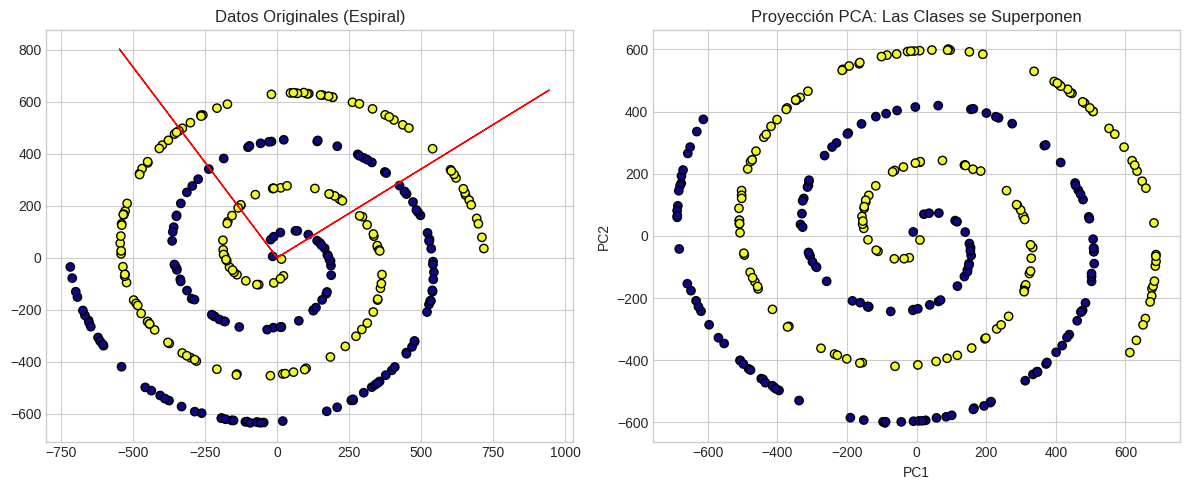

PCA colapsa las dos espirales en un ovillo informe, perdiendo la estructura de clase.


In [ ]:
# @title **Celda de Código 15: Fallo de PCA en Datos No Lineales**
# Datos en espiral
def generar_espiral(n_puntos, ruido=0.5):
    n = np.sqrt(np.random.rand(n_puntos//2)) * 360 * 2
    phi = n*np.pi/180
    x1 = -np.cos(phi)*n + np.random.randn(n_puntos//2) * ruido
    x2 = np.sin(phi)*n + np.random.randn(n_puntos//2) * ruido
    X_espiral = np.vstack((np.column_stack((x1, x2)), np.column_stack((-x1, -x2))))
    y_espiral = np.hstack((np.zeros(n_puntos//2), np.ones(n_puntos//2)))
    return X_espiral, y_espiral

X_espiral, y_espiral = generar_espiral(300, ruido=1.2)

# Aplicar PCA
pca_espiral = PCA_sklearn(n_components=2)
X_espiral_pca = pca_espiral.fit_transform(X_espiral)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_espiral[:, 0], X_espiral[:, 1], c=y_espiral, cmap='plasma', edgecolors='k')
axes[0].set_title('Datos Originales (Espiral)')
for i, (ev, vec) in enumerate(zip(pca_espiral.explained_variance_, pca_espiral.components_)):
    vec = vec * 3 * np.sqrt(ev)
    axes[0].arrow(np.mean(X_espiral[:, 0]), np.mean(X_espiral[:, 1]), vec[0], vec[1], head_width=0.5, head_length=0.5, color='red')

axes[1].scatter(X_espiral_pca[:, 0], X_espiral_pca[:, 1], c=y_espiral, cmap='plasma', edgecolors='k')
axes[1].set_title('Proyección PCA: Las Clases se Superponen')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.show()
print("PCA colapsa las dos espirales en un ovillo informe, perdiendo la estructura de clase.")

---

## 15. CONEXIÓN ESENCIAL CON SVD: El Motor Numérico de PCA

La conexión entre PCA y SVD no es solo teórica; es computacionalmente fundamental. En la práctica, `sklearn` no calcula los autovalores de $\boldsymbol{\Sigma}$, sino que aplica la Descomposición en Valores Singulares a la matriz centrada $\mathbf{X}_c$.

$$ \mathbf{X}_c = \mathbf{U} \mathbf{D} \mathbf{V}^T $$

De aquí, la matriz de covarianza es:
$$ \boldsymbol{\Sigma} = \frac{1}{n} \mathbf{X}_c^T \mathbf{X}_c = \frac{1}{n} \mathbf{V} \mathbf{D}^T \mathbf{U}^T \mathbf{U} \mathbf{D} \mathbf{V}^T = \frac{1}{n} \mathbf{V} \mathbf{D}^2 \mathbf{V}^T $$

Comparando con $\boldsymbol{\Sigma} \mathbf{W} = \mathbf{W} \boldsymbol{\Lambda}$, deducimos:
*   $\mathbf{W} = \mathbf{V}$: Los **componentes principales** (autovectores de $\boldsymbol{\Sigma}$) son los **vectores singulares derechos** de $\mathbf{X}_c$.
*   $\lambda_j = \frac{1}{n} d_j^2$: Los **autovalores** son los **valores singulares al cuadrado** divididos por $n$.
*   $\mathbf{Z} = \mathbf{X}_c \mathbf{W} = \mathbf{U} \mathbf{D} \mathbf{V}^T \mathbf{V} = \mathbf{U} \mathbf{D}$: Los **scores** (datos proyectados) son simplemente los vectores singulares izquierdos multiplicados por los valores singulares.

¡La estabilidad numérica del SVD es la razón principal de su uso universal en la implementación de PCA!

In [ ]:
# @title **Celda de Código 16: Verificación de la conexión PCA-SVD**
# Centramos datos masa-resorte
X_c_masa = X_masa - np.mean(X_masa, axis=0)
n = X_c_masa.shape[0]

# 1. Aplicamos SVD
U, S, Vt = np.linalg.svd(X_c_masa, full_matrices=False)

# 2. Comparamos con nuestra implementación PCA
pca_svd = PCA_FromScratch()
pca_svd.ajustar(X_masa)

print("=== Conexión PCA ↔ SVD ===")
print("Autovalores desde PCA (implementación propia):\n", pca_svd.autovalores_)
print("Autovalores desde SVD (d^2 / n):\n", (S**2) / n)

print("\nComponentes PCA (autovectores de Σ):\n", pca_svd.componentes_.T)  # Transponemos para comparar con Vt
print("Vectores singulares derechos V (desde SVD, Vt.T):\n", Vt.T)
print("\nLas columnas de V coinciden exactamente con los componentes principales (salvo signo).")

=== Conexión PCA ↔ SVD ===
Autovalores desde PCA (implementación propia):
 [20.05508835  0.37236554]
Autovalores desde SVD (d^2 / n):
 [20.05508835  0.37236554]

Componentes PCA (autovectores de Σ):
 [[-0.99997632 -0.00688203]
 [ 0.00688203 -0.99997632]]
Vectores singulares derechos V (desde SVD, Vt.T):
 [[ 0.99997632  0.00688203]
 [ 0.00688203 -0.99997632]]

Las columnas de V coinciden exactamente con los componentes principales (salvo signo).


---

## 16. PREGUNTAS Y EJERCICIOS

Responde las siguientes preguntas directamente en celdas de código Markdown o Python que puedes agregar al final del notebook.

**Preguntas Conceptuales:**
1.  ¿Por qué es necesario centrar los datos antes de aplicar PCA? ¿Qué fenómeno geométrico ocurre si no los centramos?
2.  Demuestra matemáticamente que el segundo componente principal $\mathbf{w}_2$ es ortogonal al primero $\mathbf{w}_1$ utilizando el Lagrangiano con dos restricciones.
3.  Explica la diferencia fundamental entre PCA y métodos de selección de características (*feature selection*).
4.  ¿Qué mide el autovalor $\lambda_j$ y por qué su suma es igual a la traza de $\boldsymbol{\Sigma}$?

**Ejercicios Prácticos:**

In [ ]:
# @title **Ejercicio 1: Implementar función de proyección para nuevos datos**
# Añade a la clase PCA_FromScratch un método `transformar_nuevo` que proyecte datos nuevos
# que no fueron parte del entrenamiento, usando la media y componentes aprendidos.
# Escribe tu código aquí:

In [ ]:
# @title **Ejercicio 2: Reconstrucción Óptima**
# Demuestra empíricamente que la reconstrucción desde k componentes de PCA
# es la mejor reconstrucción posible en el sentido de minimizar el MSE,
# comparando con una proyección aleatoria.
# Escribe tu experimento aquí:

In [ ]:
# @title **Ejercicio 3: PCA para Compresión de Imágenes (Alto Nivel)**
from sklearn.datasets import load_digits
digitos = load_digits()
X_digitos = digitos.data  # 1797 imágenes de 8x8=64 píxeles

# Aplica PCA reteniendo el 95% de la varianza.
# ¿Cuántos componentes necesitas? Reconstruye la primera imagen
# y visualízala visualmente al lado de la original. Comenta los artefactos.

---

## 17. CONCLUSIONES

Desde la intuición física de un sistema masa-resorte hasta la sólida estructura algebraica del SVD.

**Ideas Clave Aprendidas:**
*   **PCA es una rotación ortonormal del espacio** que alinea los ejes con las direcciones de máxima varianza secuencial.
*   **Se deriva de un problema de optimización exacto:** Maximizar la varianza proyectada equivale a resolver el problema de autovalores de la matriz de covarianza.
*   **La varianza explicada** es una herramienta fundamental para elegir la dimensionalidad $k$, cuantificando la pérdida de información.
*   **PCA = SVD de la matriz centrada:** Esta conexión no solo es matemáticamente interesante, sino que es el corazón de las implementaciones computacionales modernas y numéricamente estables.

**¿Cuándo y Cuándo No Usar PCA?**
*   **Úsenlo** para reducción de dimensionalidad lineal, visualización de datos de alta dimensión, preprocesamiento para eliminar multicolinealidad antes de una regresión, compresión con pérdida y filtrado de ruido gaussiano.
*   **No lo usen** si la estructura de los datos es fundamentalmente no lineal (uso de manifolds). En esos casos, exploren métodos como t-SNE, UMAP o Kernel PCA.

